In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# IMPORT LIBRARIES AND PROJECT PATHS

import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)

# Reproducibility

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Device

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# Project folders

BASE_DIR = Path(
    "/content/drive/MyDrive/intentmap-nids/intentmap-nids"
)

DATA_DIR = BASE_DIR / "data" / "processed"
MODEL_DIR = BASE_DIR / "models"
REPORT_DIR = BASE_DIR / "reports"
CONFIG_DIR = BASE_DIR / "config"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)
CONFIG_DIR.mkdir(parents=True, exist_ok=True)


print("BASE_DIR:", BASE_DIR)
print("DATA_DIR:", DATA_DIR)
print("DATA_DIR exists:", DATA_DIR.exists())

Device: cpu
BASE_DIR: /content/drive/MyDrive/intentmap-nids/intentmap-nids
DATA_DIR: /content/drive/MyDrive/intentmap-nids/intentmap-nids/data/processed
DATA_DIR exists: True


In [3]:
# CHECK PROCESSED DATA FILES

print("Processed files:")

for file in sorted(DATA_DIR.iterdir()):
    print("-", file.name)

Processed files:
- config
- models
- reports
- test_dedup.npz
- test_full.npz
- train_normal.npz
- val_normal.npz


In [4]:
# LOAD TRAIN / VALIDATION / TEST DATA

def load_npz(path):

    data = np.load(path)

    X = data["X"]

    y = (
        data["y"]
        if "y" in data.files
        else None
    )

    return X, y


X_train, _ = load_npz(
    DATA_DIR / "train_normal.npz"
)

X_val, _ = load_npz(
    DATA_DIR / "val_normal.npz"
)

X_test, y_test = load_npz(
    DATA_DIR / "test_full.npz"
)


# Convert to float32 for PyTorch
X_train = X_train.astype(np.float32)
X_val = X_val.astype(np.float32)
X_test = X_test.astype(np.float32)


print("Normal training data:", X_train.shape)
print("Normal validation data:", X_val.shape)
print("Full testing data:", X_test.shape)


print(
    "Normal test records:",
    (y_test == 0).sum()
)

print(
    "Attack test records:",
    (y_test == 1).sum()
)

Normal training data: (41065, 41)
Normal validation data: (10266, 41)
Full testing data: (82332, 41)
Normal test records: 37000
Attack test records: 45332


In [5]:
# VERIFY INPUT DIMENSIONS AND DATA QUALITY

assert (
    X_train.shape[1]
    ==
    X_val.shape[1]
    ==
    X_test.shape[1]
), "Feature dimensions do not match."


print(
    "All datasets contain",
    X_train.shape[1],
    "model-input features."
)


print("\nTraining minimum:", np.min(X_train))
print("Training maximum:", np.max(X_train))
print("Training mean:", np.mean(X_train))
print("Training std:", np.std(X_train))

print("\nAny NaN:", np.isnan(X_train).any())
print("Any infinity:", np.isinf(X_train).any())

All datasets contain 41 model-input features.

Training minimum: -3.3884416
Training maximum: 7.9811873
Training mean: 0.08408545
Training std: 0.5488584

Any NaN: False
Any infinity: False


In [6]:
# CREATE PYTORCH DATA LOADER

BATCH_SIZE = 512

train_tensor = torch.tensor(X_train, dtype=torch.float32)
train_dataset = TensorDataset(train_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

print("Training batches:", len(train_loader))

Training batches: 81


In [7]:
# DEFINE DEEP SVDD NETWORK

# Maps normal traffic into a compact representation
# around a centre point.

class DeepSVDDNet(nn.Module):
    def __init__(self, input_dim, representation_dim=16):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64, bias=False),
            nn.ReLU(),
            nn.Linear(64, 32, bias=False),
            nn.ReLU(),
            nn.Linear(32, representation_dim, bias=False)
        )

    def forward(self, x):
        return self.network(x)


INPUT_DIM = X_train.shape[1]
REPRESENTATION_DIM = 16

deep_svdd_model = DeepSVDDNet(
    input_dim=INPUT_DIM,
    representation_dim=REPRESENTATION_DIM
).to(DEVICE)

print(deep_svdd_model)

DeepSVDDNet(
  (network): Sequential(
    (0): Linear(in_features=41, out_features=64, bias=False)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=False)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=16, bias=False)
  )
)


In [8]:
# INITIALISE DEEP SVDD CENTRE
# The centre c is calculated from the mean representation
# of normal training records before Deep SVDD training.

def initialise_center(
    model,
    loader,
    device,
    eps=0.1
):

    model.eval()
    n_samples = 0
    c = torch.zeros(
        REPRESENTATION_DIM,
        device=device
    )


    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            outputs = model(x)
            c += outputs.sum(dim=0)
            n_samples += outputs.shape[0]

    c /= n_samples

    # Avoid centre values extremely close to zero
    c[(torch.abs(c) < eps) & (c < 0)] = -eps
    c[(torch.abs(c) < eps) & (c > 0)] = eps
    return c
CENTER = initialise_center(
    deep_svdd_model,
    train_loader,
    DEVICE
)
print("Deep SVDD centre:")
print(CENTER)

Deep SVDD centre:
tensor([ 0.1000,  0.1000, -0.1000,  0.1000,  0.1000,  0.1000, -0.1000,  0.1000,
        -0.1000, -0.1000,  0.1000,  0.1000,  0.1000,  0.1000,  0.1000,  0.1000])


In [9]:
# TRAIN DEEP SVDD

EPOCHS = 30
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-6

optimizer = torch.optim.Adam(
    deep_svdd_model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY)

training_losses = []
print("Starting Deep SVDD training...")

for epoch in range(EPOCHS):

    deep_svdd_model.train()
    running_loss = 0.0
    samples_seen = 0

    for batch in train_loader:
        x = batch[0].to(DEVICE)
        optimizer.zero_grad()
        outputs = deep_svdd_model(x)
        distances = torch.sum((outputs - CENTER) ** 2,dim=1)
        loss = torch.mean(distances )
        loss.backward()
        optimizer.step()
        running_loss += (loss.item()* x.size(0))
        samples_seen += x.size(0)
    epoch_loss = (running_loss / samples_seen )
    training_losses.append(
        epoch_loss )


    print(
        f"Epoch "
        f"{epoch + 1:02d}/{EPOCHS} "
        f"- Loss: "
        f"{epoch_loss:.8f}" )


print("Deep SVDD training completed.")

Starting Deep SVDD training...
Epoch 01/30 - Loss: 0.01632851
Epoch 02/30 - Loss: 0.00118565
Epoch 03/30 - Loss: 0.00051651
Epoch 04/30 - Loss: 0.00030546
Epoch 05/30 - Loss: 0.00020710
Epoch 06/30 - Loss: 0.00015139
Epoch 07/30 - Loss: 0.00011646
Epoch 08/30 - Loss: 0.00009233
Epoch 09/30 - Loss: 0.00007516
Epoch 10/30 - Loss: 0.00006268
Epoch 11/30 - Loss: 0.00005253
Epoch 12/30 - Loss: 0.00004484
Epoch 13/30 - Loss: 0.00003854
Epoch 14/30 - Loss: 0.00003347
Epoch 15/30 - Loss: 0.00002941
Epoch 16/30 - Loss: 0.00002595
Epoch 17/30 - Loss: 0.00002298
Epoch 18/30 - Loss: 0.00002051
Epoch 19/30 - Loss: 0.00001829
Epoch 20/30 - Loss: 0.00001640
Epoch 21/30 - Loss: 0.00001472
Epoch 22/30 - Loss: 0.00001327
Epoch 23/30 - Loss: 0.00001211
Epoch 24/30 - Loss: 0.00001096
Epoch 25/30 - Loss: 0.00000997
Epoch 26/30 - Loss: 0.00000909
Epoch 27/30 - Loss: 0.00000855
Epoch 28/30 - Loss: 0.00000771
Epoch 29/30 - Loss: 0.00000725
Epoch 30/30 - Loss: 0.00000656
Deep SVDD training completed.


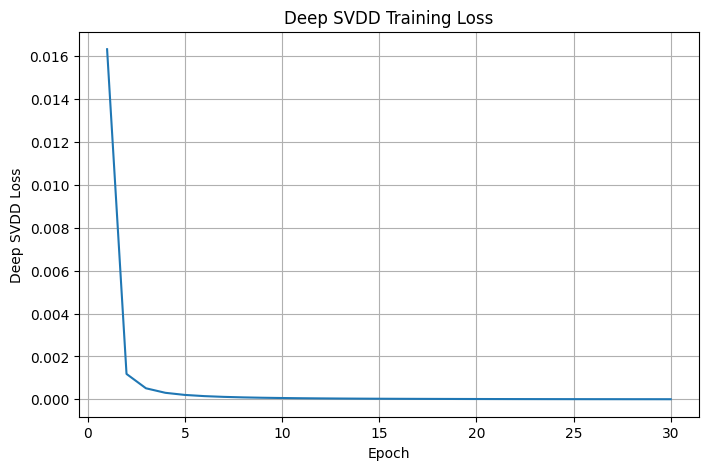

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/deep_svdd_training_loss.png


In [10]:
# PLOT TRAINING LOSS

plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), training_losses)

plt.xlabel("Epoch")
plt.ylabel("Deep SVDD Loss")
plt.title("Deep SVDD Training Loss")
plt.grid(True)
DEEP_SVDD_LOSS_PLOT = (REPORT_DIR / "deep_svdd_training_loss.png")
plt.savefig(DEEP_SVDD_LOSS_PLOT, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", DEEP_SVDD_LOSS_PLOT)

In [11]:
# CREATE DEEP SVDD ANOMALY SCORES

def deep_svdd_scores(
    model,
    X,
    center,
    device,
    batch_size=1024
):

    model.eval()
    X_tensor = torch.tensor(X, dtype=torch.float32)

    loader = DataLoader(
        TensorDataset(X_tensor),
        batch_size=batch_size,
        shuffle=False)
    scores = []
    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            outputs = model(x)
            distances = torch.sum((outputs - center) ** 2,dim=1)

            scores.extend(
                distances
                .cpu()
                .numpy())

    return np.array(scores)

train_scores = deep_svdd_scores(deep_svdd_model, X_train, CENTER, DEVICE)
val_scores = deep_svdd_scores(deep_svdd_model, X_val, CENTER, DEVICE)
test_scores = deep_svdd_scores( deep_svdd_model, X_test, CENTER, DEVICE)
print("Training score mean:", train_scores.mean())
print("Validation score mean:", val_scores.mean())
print("Test score mean:", test_scores.mean())
print("\nHigher Deep SVDD score = more anomalous.")

Training score mean: 7.157157e-06
Validation score mean: 7.3628007e-06
Test score mean: 0.00010264702

Higher Deep SVDD score = more anomalous.


In [12]:
# CALIBRATE FALSE-POSITIVE BUDGET THRESHOLDS

fp_budgets = {
    "0.5% budget": 0.005,
    "1% budget": 0.01,
    "3% budget": 0.03
}

thresholds = {}

for label, budget in fp_budgets.items():
    threshold = np.quantile(
        val_scores,
        1 - budget)

    thresholds[label] = threshold
    val_predictions = (
        val_scores >= threshold
    ).astype(int)

    validation_fpr = (
        val_predictions.mean())

    print(
        f"{label}: "
        f"threshold={threshold:.8f}, "
        f"validation anomaly rate="
        f"{validation_fpr:.4%}")

0.5% budget: threshold=0.00008080, validation anomaly rate=0.5065%
1% budget: threshold=0.00005489, validation anomaly rate=1.0033%
3% budget: threshold=0.00003072, validation anomaly rate=3.0002%


In [13]:
# EVALUATION FUNCTION

def evaluate_threshold(y_true, scores, threshold):
    predictions = (scores >= threshold).astype(int)

    precision = precision_score(y_true, predictions, zero_division=0)
    recall = recall_score(y_true, predictions, zero_division=0)
    f1 = f1_score(y_true, predictions, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(
        y_true,
        predictions,
        labels=[0, 1]
    ).ravel()

    actual_fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    false_alerts_per_1000 = actual_fpr * 1000

    return {
        "Threshold": threshold,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Actual FPR": actual_fpr,
        "False alerts per 1000": false_alerts_per_1000,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

In [14]:
# EVALUATE ALL FALSE-POSITIVE BUDGETS

evaluation_rows = []
for label, threshold in thresholds.items():
    metrics = evaluate_threshold(
        y_test,
        test_scores,
        threshold)
    metrics["Budget"] = label
    evaluation_rows.append(metrics)
deep_svdd_budget_results = pd.DataFrame(evaluation_rows)

deep_svdd_budget_results = deep_svdd_budget_results[[
        "Budget",
        "Threshold",
        "Precision",
        "Recall",
        "F1",
        "Actual FPR",
        "False alerts per 1000",
        "TN",
        "FP",
        "FN",
        "TP"]]
display(deep_svdd_budget_results)

,Budget,Threshold,Precision,Recall,F1,Actual FPR,False alerts per 1000,TN,FP,FN,TP
0,0.5% budget,0.000081,0.940044,0.532979,0.680266,0.041649,41.648649,35459,1541,21171,24161
1,1% budget,0.000055,0.927429,0.594547,0.724584,0.057000,57.000000,34891,2109,18380,26952
2,3% budget,0.000031,0.907464,0.693329,0.786074,0.086622,86.621622,33795,3205,13902,31430


In [15]:
# ROC-AUC AND PR-AUC

deep_svdd_roc_auc = roc_auc_score(
    y_test,
    test_scores)

deep_svdd_pr_auc = average_precision_score(
    y_test,
    test_scores)

print(
    f"Deep SVDD ROC-AUC: "
    f"{deep_svdd_roc_auc:.4f}")

print(
    f"Deep SVDD PR-AUC: "
    f"{deep_svdd_pr_auc:.4f}")

Deep SVDD ROC-AUC: 0.8871
Deep SVDD PR-AUC: 0.8955


In [16]:
# SAVE BUDGET RESULTS

DEEP_SVDD_BUDGET_FILE = (REPORT_DIR / "deep_svdd_budget_results.csv")
deep_svdd_budget_results.to_csv(DEEP_SVDD_BUDGET_FILE, index=False)
print("Saved:", DEEP_SVDD_BUDGET_FILE)

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/deep_svdd_budget_results.csv


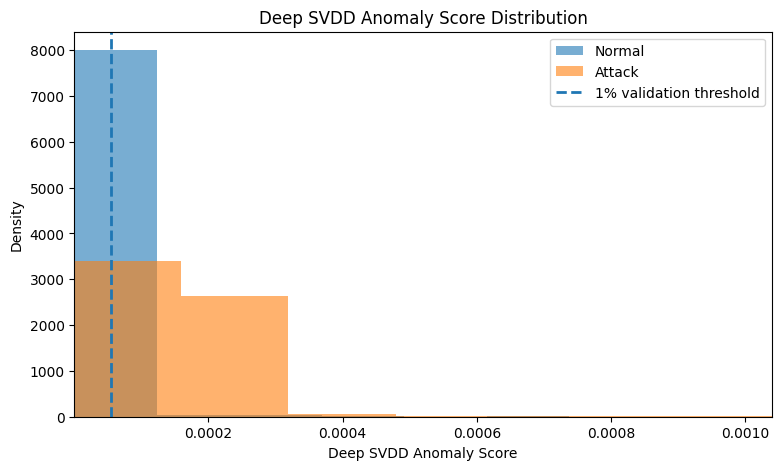

Saved: /content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/deep_svdd_scores.png


In [17]:
# PLOT NORMAL VS ATTACK SCORES

normal_scores = test_scores[y_test == 0]
attack_scores = test_scores[y_test == 1]

plt.figure(figsize=(9, 5))

plt.hist(
    normal_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Normal")

plt.hist(
    attack_scores,
    bins=100,
    alpha=0.6,
    density=True,
    label="Attack")

plt.axvline(
    thresholds["1% budget"],
    linestyle="--",
    linewidth=2,
    label="1% validation threshold")

plt.xlabel("Deep SVDD Anomaly Score")
plt.ylabel("Density")
plt.title("Deep SVDD Anomaly Score Distribution")
plt.legend()

plt.xlim(
    np.percentile(test_scores, 0.1),
    np.percentile(test_scores, 99))

DEEP_SVDD_SCORE_PLOT = REPORT_DIR / "deep_svdd_scores.png"

plt.savefig(
    DEEP_SVDD_SCORE_PLOT,
    dpi=300,
    bbox_inches="tight")

plt.show()
print("Saved:", DEEP_SVDD_SCORE_PLOT)

In [18]:
# CREATE PREDICTIONS AT EACH BUDGET

threshold_005 = thresholds["0.5% budget"]
threshold_01 = thresholds["1% budget"]
threshold_03 = thresholds["3% budget"]

deep_svdd_pred_005 = (test_scores >= threshold_005).astype(int)
deep_svdd_pred_01 = (test_scores >= threshold_01).astype(int)
deep_svdd_pred_03 = (test_scores >= threshold_03).astype(int)

In [19]:
# CREATE DASHBOARD-READY DATAFRAME

deep_svdd_dashboard_results = pd.DataFrame({
    "record_id": range(1, len(test_scores) + 1),
    "actual_label": y_test,
    "actual_class": ["Attack" if y == 1 else "Normal" for y in y_test],
    "deep_svdd_score": test_scores,
    "deep_svdd_prediction_0.5pct": deep_svdd_pred_005,
    "deep_svdd_prediction_1pct": deep_svdd_pred_01,
    "deep_svdd_prediction_3pct": deep_svdd_pred_03,
    "deep_svdd_status_0.5pct": ["Anomaly" if p == 1 else "Normal" for p in deep_svdd_pred_005],
    "deep_svdd_status_1pct": ["Anomaly" if p == 1 else "Normal" for p in deep_svdd_pred_01],
    "deep_svdd_status_3pct": ["Anomaly" if p == 1 else "Normal" for p in deep_svdd_pred_03]
})

# Use the 1% budget as the default dashboard setting
deep_svdd_dashboard_results["default_threshold"] = threshold_01
deep_svdd_dashboard_results["default_prediction"] = deep_svdd_pred_01
deep_svdd_dashboard_results["default_status"] = [
    "Anomaly" if p == 1 else "Normal" for p in deep_svdd_pred_01
]

deep_svdd_dashboard_results["correct_prediction"] = (
    deep_svdd_dashboard_results["default_prediction"]
    == deep_svdd_dashboard_results["actual_label"]
)

display(deep_svdd_dashboard_results.head(10))

,record_id,actual_label,actual_class,deep_svdd_score,deep_svdd_prediction_0.5pct,deep_svdd_prediction_1pct,deep_svdd_prediction_3pct,deep_svdd_status_0.5pct,deep_svdd_status_1pct,deep_svdd_status_3pct,default_threshold,default_prediction,default_status,correct_prediction
0,1,0,Normal,0.000008,0,0,0,Normal,Normal,Normal,0.000055,0,Normal,True
1,2,0,Normal,0.000005,0,0,0,Normal,Normal,Normal,0.000055,0,Normal,True
2,3,0,Normal,0.000004,0,0,0,Normal,Normal,Normal,0.000055,0,Normal,True
3,4,0,Normal,0.000006,0,0,0,Normal,Normal,Normal,0.000055,0,Normal,True
4,5,0,Normal,0.000006,0,0,0,Normal,Normal,Normal,0.000055,0,Normal,True
5,6,0,Normal,0.000008,0,0,0,Normal,Normal,Normal,0.000055,0,Normal,True
6,7,0,Normal,0.000005,0,0,0,Normal,Normal,Normal,0.000055,0,Normal,True
7,8,0,Normal,0.000011,0,0,0,Normal,Normal,Normal,0.000055,0,Normal,True
8,9,0,Normal,0.000065,0,1,1,Normal,Anomaly,Anomaly,0.000055,1,Anomaly,False
9,10,0,Normal,0.000065,0,1,1,Normal,Anomaly,Anomaly,0.000055,1,Anomaly,False


In [20]:
# SAVE DASHBOARD CSV

DEEP_SVDD_DASHBOARD_FILE = REPORT_DIR / "deep_svdd_dashboard_results.csv"

deep_svdd_dashboard_results.to_csv(
    DEEP_SVDD_DASHBOARD_FILE,
    index=False
)

print("Deep SVDD dashboard results saved:")
print(DEEP_SVDD_DASHBOARD_FILE)
print("Shape:", deep_svdd_dashboard_results.shape)

Deep SVDD dashboard results saved:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/reports/deep_svdd_dashboard_results.csv
Shape: (82332, 14)


In [21]:
# SAVE DEEP SVDD MODEL

DEEP_SVDD_MODEL_FILE = MODEL_DIR / "deep_svdd_model.pt"

torch.save({
    "model_state_dict": deep_svdd_model.state_dict(),
    "center": CENTER.detach().cpu().numpy(),
    "input_dim": INPUT_DIM,
    "representation_dim": REPRESENTATION_DIM
}, DEEP_SVDD_MODEL_FILE)

print("Saved Deep SVDD model:")
print(DEEP_SVDD_MODEL_FILE)

Saved Deep SVDD model:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/models/deep_svdd_model.pt


In [22]:
# SAVE DEEP SVDD CONFIGURATION

DEEP_SVDD_CONFIG_FILE = CONFIG_DIR / "deep_svdd_model.json"

deep_svdd_information = {
    "model": "Deep SVDD",
    "model_type": "Deep unsupervised comparison model",
    "purpose": "Network anomaly detection",
    "training_data": "train_normal.npz",
    "validation_data": "val_normal.npz",
    "test_data": "test_full.npz",
    "training_strategy": "Normal-only training",
    "input_features": int(INPUT_DIM),
    "representation_dim": REPRESENTATION_DIM,
    "hidden_layers": [64, 32],
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "random_seed": SEED,
    "score_direction": "Higher score means more anomalous",
    "score_definition": "Squared Euclidean distance from Deep SVDD centre",
    "roc_auc": float(deep_svdd_roc_auc),
    "pr_auc": float(deep_svdd_pr_auc),
    "thresholds": {
        label: float(value)
        for label, value in thresholds.items()
    }
}

with open(DEEP_SVDD_CONFIG_FILE, "w") as f:
    json.dump(deep_svdd_information, f, indent=4)

print("Saved configuration:")
print(DEEP_SVDD_CONFIG_FILE)

Saved configuration:
/content/drive/MyDrive/intentmap-nids/intentmap-nids/config/deep_svdd_model.json


In [23]:
# VERIFY OUTPUT FILES

files_to_check = [
    DEEP_SVDD_MODEL_FILE,
    DEEP_SVDD_CONFIG_FILE,
    DEEP_SVDD_BUDGET_FILE,
    DEEP_SVDD_DASHBOARD_FILE,
    DEEP_SVDD_SCORE_PLOT,
    DEEP_SVDD_LOSS_PLOT
]

print("\nDeep SVDD implementation completed.")

for file in files_to_check:
    print(file.name, "->", file.exists())

print("\nFiles created:")
print("1. deep_svdd_model.pt")
print("2. deep_svdd_model.json")
print("3. deep_svdd_budget_results.csv")
print("4. deep_svdd_dashboard_results.csv")
print("5. deep_svdd_scores.png")
print("6. deep_svdd_training_loss.png")


Deep SVDD implementation completed.
deep_svdd_model.pt -> True
deep_svdd_model.json -> True
deep_svdd_budget_results.csv -> True
deep_svdd_dashboard_results.csv -> True
deep_svdd_scores.png -> True
deep_svdd_training_loss.png -> True

Files created:
1. deep_svdd_model.pt
2. deep_svdd_model.json
3. deep_svdd_budget_results.csv
4. deep_svdd_dashboard_results.csv
5. deep_svdd_scores.png
6. deep_svdd_training_loss.png


In [24]:
# CREATE DEEP SVDD ZIP PACKAGE

import zipfile
from google.colab import files

DEEP_SVDD_ZIP_FILE = "/content/Deep_SVDD_Results.zip"

files_to_zip = [
    DEEP_SVDD_MODEL_FILE,
    DEEP_SVDD_CONFIG_FILE,
    DEEP_SVDD_BUDGET_FILE,
    DEEP_SVDD_DASHBOARD_FILE,
    DEEP_SVDD_SCORE_PLOT,
    DEEP_SVDD_LOSS_PLOT
]

with zipfile.ZipFile(DEEP_SVDD_ZIP_FILE, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file_path in files_to_zip:
        if file_path.exists():
            zipf.write(file_path, arcname=file_path.name)
            print("Added:", file_path.name)
        else:
            print("Missing:", file_path)

print("\nDeep SVDD package created successfully:")
print(DEEP_SVDD_ZIP_FILE)

files.download(DEEP_SVDD_ZIP_FILE)

Added: deep_svdd_model.pt
Added: deep_svdd_model.json
Added: deep_svdd_budget_results.csv
Added: deep_svdd_dashboard_results.csv
Added: deep_svdd_scores.png
Added: deep_svdd_training_loss.png

Deep SVDD package created successfully:
/content/Deep_SVDD_Results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>